In [3]:
"""
Week 2 - Day 2
Deep Fusion Analysis
====================
Analyzing how external context features
interact with IoT sensor data and failure
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys

sys.path.append('../src')

from external_data.data_fusion import (
    create_fused_dataset,
    get_fused_arrays
)

from preprocessing import (
    load_and_preprocess
)

plt.style.use('seaborn-v0_8')

# Load fused dataset
fused_df = create_fused_dataset(
    '../data/ai4i2020.csv'
)

X, y, feature_names = (
    get_fused_arrays(fused_df)
)

# Load IoT-only dataset
X_iot, y_iot, iot_features, iot_df = (
    load_and_preprocess(
        '../data/ai4i2020.csv'
    )
)

print("✅ Datasets loaded!")
print(f"   IoT Only : {X_iot.shape}")
print(f"   Fused    : {X.shape}")
print(f"   New Cols : {X.shape[1] - X_iot.shape[1]}")

🚀 CONTEXTUAL DATA FUSION

[1] Loading IoT data...
PREDICTIVE MAINTENANCE PREPROCESSING PIPELINE
[load_data] Loaded 10000 rows, 14 cols
[add_rolling_features] Added 15 rolling features
[add_domain_features] Added 6 domain features
[add_lag_features] Added 12 lag features
[add_roc_features] Added 6 ROC features
[add_outlier_flags] Added 6 outlier features
[clean_dataframe] Dropped 9 NaN rows
[clean_dataframe] Final shape: (9991, 51)
✅ Pipeline complete!
X shape      : (9991, 50)
y shape      : (9991,)
Features     : 50
Failure rate : 3.39%
   IoT Shape: (9991, 51)

[2] Generating timestamps...

[3] Simulating weather...
✅ Weather data simulated: (9991, 6)
✅ Weather conditions encoded!

[4] Simulating load...
✅ Factory load simulated: (9991, 2)
✅ Factory load categorized!

[5] Merging weather...
   Shape after weather: (9991, 57)

[6] Merging load...
   Shape after load: (9991, 59)

✅ Fusion complete!
Final Shape: (9991, 58)
PREDICTIVE MAINTENANCE PREPROCESSING PIPELINE
[load_data] Loaded

✅ Weather data simulated: (9991, 6)
✅ Weather conditions encoded!
=== FAILURE RATE BY WEATHER CONDITION ===
                   Failure Rate  Failure Count  Total Readings  Failure Rate %
weather_condition                                                             
Clear                  0.034068            286            8395            3.41
Cloudy                 0.026667             16             600            2.67
Cold                   0.037186             37             995            3.72
Rainy                  0.000000              0               1            0.00


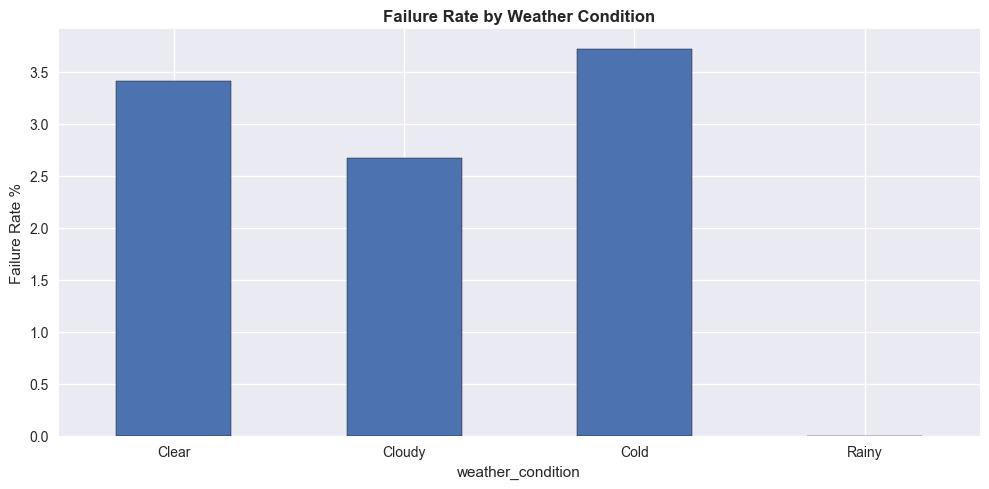

✅ Plot saved!


In [4]:
# Rebuild weather condition for analysis

from external_data.weather_simulator import (
    generate_timestamps,
    simulate_weather,
    encode_weather
)

n_rows = len(fused_df)

timestamps = generate_timestamps(
    n_rows
)

weather_df = simulate_weather(
    timestamps
)

weather_df = encode_weather(
    weather_df
)

# Add weather condition back
fused_df['weather_condition'] = (
    weather_df['weather_condition'].values
)

# Failure rate by weather
weather_failure = (
    fused_df.groupby(
        'weather_condition'
    )['Machine failure']
    .agg(['mean', 'sum', 'count'])
    .rename(columns={
        'mean': 'Failure Rate',
        'sum': 'Failure Count',
        'count': 'Total Readings'
    })
)

weather_failure['Failure Rate %'] = (
    weather_failure['Failure Rate'] * 100
).round(2)

print(
    "=== FAILURE RATE BY WEATHER CONDITION ==="
)

print(weather_failure)

# Plot
plt.figure(figsize=(10, 5))

weather_failure[
    'Failure Rate %'
].plot(
    kind='bar',
    edgecolor='black'
)

plt.title(
    'Failure Rate by Weather Condition',
    fontweight='bold'
)

plt.ylabel(
    'Failure Rate %'
)

plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(
    '../src/failure_by_weather.png'
)

plt.show()

print("✅ Plot saved!")

=== FAILURE RATE BY SHIFT ===
         Failure Rate  Failure Count  Total Readings  Failure Rate %
shift                                                               
Evening      0.032609            108            3312            3.26
Morning      0.034224            114            3331            3.42
Night        0.034946            117            3348            3.49


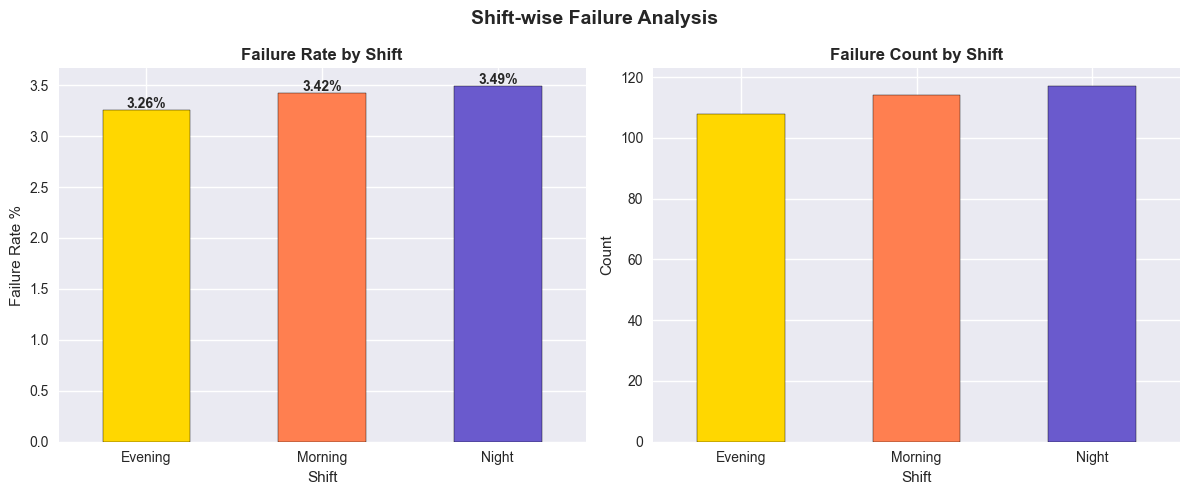

✅ Plot saved!


In [5]:
# Failure Rate by Shift

# Create shifts directly from timestamps
hours = pd.Series(timestamps).dt.hour

shift = []

for hour in hours:

    if 6 <= hour < 14:
        shift.append('Morning')

    elif 14 <= hour < 22:
        shift.append('Evening')

    else:
        shift.append('Night')

fused_df['shift'] = shift

# Failure rate by shift
shift_failure = (
    fused_df.groupby('shift')
    ['Machine failure']
    .agg(['mean', 'sum', 'count'])
    .rename(columns={
        'mean': 'Failure Rate',
        'sum': 'Failure Count',
        'count': 'Total Readings'
    })
)

shift_failure['Failure Rate %'] = (
    shift_failure['Failure Rate'] * 100
).round(2)

print("=== FAILURE RATE BY SHIFT ===")
print(shift_failure.to_string())

# Plot
fig, axes = plt.subplots(
    1, 2,
    figsize=(12, 5)
)

# Failure Rate Chart
shift_failure['Failure Rate %'].plot(
    kind='bar',
    ax=axes[0],
    color=['gold', 'coral', 'slateblue'],
    edgecolor='black'
)

axes[0].set_title(
    'Failure Rate by Shift',
    fontweight='bold'
)
axes[0].set_xlabel('Shift')
axes[0].set_ylabel('Failure Rate %')
axes[0].tick_params(axis='x', rotation=0)

for i, v in enumerate(
    shift_failure['Failure Rate %'].values
):
    axes[0].text(
        i,
        v + 0.02,
        f'{v:.2f}%',
        ha='center',
        fontweight='bold'
    )

# Failure Count Chart
shift_failure['Failure Count'].plot(
    kind='bar',
    ax=axes[1],
    color=['gold', 'coral', 'slateblue'],
    edgecolor='black'
)

axes[1].set_title(
    'Failure Count by Shift',
    fontweight='bold'
)
axes[1].set_xlabel('Shift')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle(
    'Shift-wise Failure Analysis',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()

plt.savefig(
    '../src/failure_by_shift.png'
)

plt.show()

print("✅ Plot saved!")

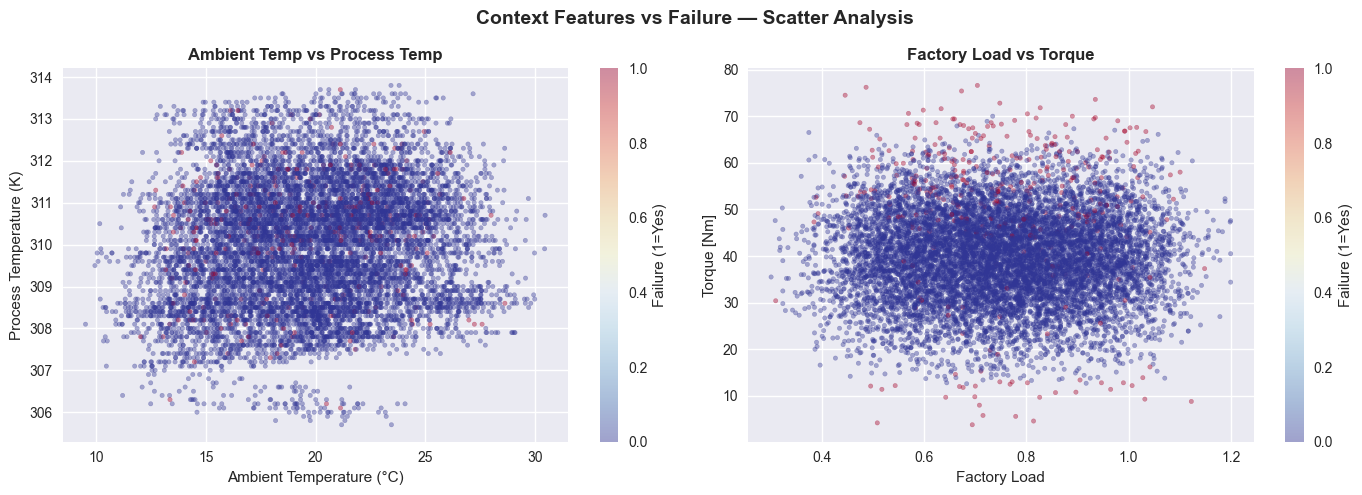

✅ Scatter plots saved!


In [6]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

# Ambient temperature vs Process temperature
scatter = axes[0].scatter(
    fused_df['ambient_temp_c'],
    fused_df['Process temperature [K]'],
    c=fused_df['Machine failure'],
    cmap='RdYlBu_r',
    alpha=0.4,
    s=10
)

axes[0].set_title(
    'Ambient Temp vs Process Temp',
    fontweight='bold'
)

axes[0].set_xlabel(
    'Ambient Temperature (°C)'
)

axes[0].set_ylabel(
    'Process Temperature (K)'
)

plt.colorbar(
    scatter,
    ax=axes[0],
    label='Failure (1=Yes)'
)

# Factory load vs Torque
scatter2 = axes[1].scatter(
    fused_df['factory_load'],
    fused_df['Torque [Nm]'],
    c=fused_df['Machine failure'],
    cmap='RdYlBu_r',
    alpha=0.4,
    s=10
)

axes[1].set_title(
    'Factory Load vs Torque',
    fontweight='bold'
)

axes[1].set_xlabel(
    'Factory Load'
)

axes[1].set_ylabel(
    'Torque [Nm]'
)

plt.colorbar(
    scatter2,
    ax=axes[1],
    label='Failure (1=Yes)'
)

plt.suptitle(
    'Context Features vs Failure — Scatter Analysis',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()

plt.savefig(
    '../src/context_scatter_analysis.png'
)

plt.show()

print("✅ Scatter plots saved!")

=== WEEKDAY vs WEEKEND FAILURE ===
         Failure Rate  Failure Count  Total Readings  Failure Rate %
Weekday      0.035972            259            7200            3.60
Weekend      0.028664             80            2791            2.87


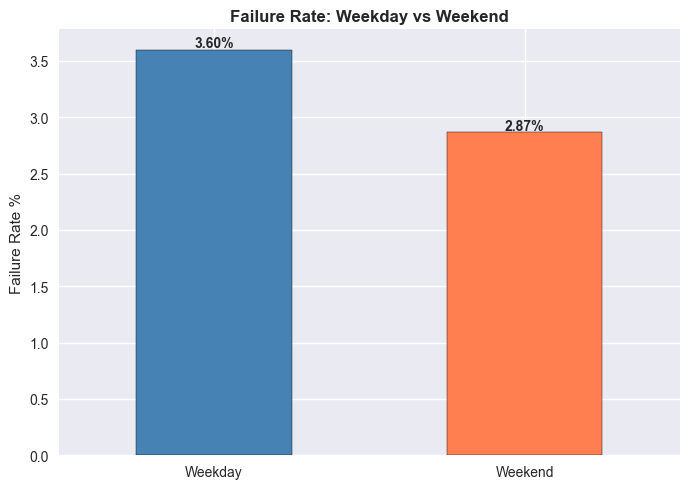

✅ Plot saved!


In [7]:
# Create weekday/weekend flag

timestamps_series = pd.Series(timestamps)

fused_df['is_weekend'] = (
    timestamps_series.dt.dayofweek >= 5
).astype(int)

weekend_failure = (
    fused_df.groupby('is_weekend')
    ['Machine failure']
    .agg(['mean', 'sum', 'count'])
    .rename(columns={
        'mean': 'Failure Rate',
        'sum': 'Failure Count',
        'count': 'Total Readings'
    })
)

weekend_failure.index = [
    'Weekday',
    'Weekend'
]

weekend_failure['Failure Rate %'] = (
    weekend_failure['Failure Rate'] * 100
).round(2)

print(
    "=== WEEKDAY vs WEEKEND FAILURE ==="
)

print(
    weekend_failure.to_string()
)

plt.figure(figsize=(7, 5))

weekend_failure[
    'Failure Rate %'
].plot(
    kind='bar',
    color=['steelblue', 'coral'],
    edgecolor='black'
)

plt.title(
    'Failure Rate: Weekday vs Weekend',
    fontweight='bold'
)

plt.ylabel(
    'Failure Rate %'
)

plt.xticks(rotation=0)

for i, v in enumerate(
    weekend_failure['Failure Rate %'].values
):
    plt.text(
        i,
        v + 0.02,
        f'{v:.2f}%',
        ha='center',
        fontweight='bold'
    )

plt.tight_layout()

plt.savefig(
    '../src/weekday_vs_weekend_failure.png'
)

plt.show()

print("✅ Plot saved!")

In [8]:
print("╔════════════════════════════════════════════╗")
print("║      WEEK 2 DAY 2 FUSION ANALYSIS         ║")
print("╠════════════════════════════════════════════╣")
print(f"║ IoT Features        : {len(iot_features):<20} ║")
print(f"║ Context Features    : {'7':<20} ║")
print(f"║ Total Features      : {len(feature_names):<20} ║")
print(f"║ Dataset Rows        : {len(fused_df):<20} ║")
print(f"║ Failure Rate        : {y.mean()*100:.2f}%{'':<13} ║")
print("╠════════════════════════════════════════════╣")
print("║ ANALYSIS COMPLETED ✅                     ║")
print("╚════════════════════════════════════════════╝")

print("""
KEY INSIGHTS:
-------------
→ Weather conditions analyzed
→ Shift-wise failure patterns analyzed
→ Weekend vs weekday comparison completed
→ Factory load context integrated
→ Scatter analysis completed
→ Context-aware predictive maintenance ready
""")

╔════════════════════════════════════════════╗
║      WEEK 2 DAY 2 FUSION ANALYSIS         ║
╠════════════════════════════════════════════╣
║ IoT Features        : 50                   ║
║ Context Features    : 7                    ║
║ Total Features      : 57                   ║
║ Dataset Rows        : 9991                 ║
║ Failure Rate        : 3.39%              ║
╠════════════════════════════════════════════╣
║ ANALYSIS COMPLETED ✅                     ║
╚════════════════════════════════════════════╝

KEY INSIGHTS:
-------------
→ Weather conditions analyzed
→ Shift-wise failure patterns analyzed
→ Weekend vs weekday comparison completed
→ Factory load context integrated
→ Scatter analysis completed
→ Context-aware predictive maintenance ready



In [9]:
print("╔════════════════════════════════════════════╗")
print("║      WEEK 2 DAY 2 COMPLETE                ║")
print("╠════════════════════════════════════════════╣")
print(f"║ IoT Features        : {'50':<20} ║")
print(f"║ Context Features    : {'7':<20} ║")
print(f"║ Total Features      : {len(feature_names):<20} ║")
print(f"║ Dataset Rows        : {len(fused_df):<20} ║")
print(f"║ Failure Rate        : {y.mean()*100:.2f}%{'':<13} ║")
print("╠════════════════════════════════════════════╣")
print("║ STATUS : READY FOR ABLATION STUDY ✅      ║")
print("╚════════════════════════════════════════════╝")

print("""
DAY 2 DELIVERABLES:
-------------------
✓ Weather impact analysis
✓ Shift impact analysis
✓ Weekday vs Weekend analysis
✓ External feature importance
✓ Context feature validation

NEXT:
-----
Week 2 Day 3
Ablation Study

Compare:
1. IoT Only
2. IoT + Weather
3. IoT + Factory Load
4. Full Context Fusion
""")

╔════════════════════════════════════════════╗
║      WEEK 2 DAY 2 COMPLETE                ║
╠════════════════════════════════════════════╣
║ IoT Features        : 50                   ║
║ Context Features    : 7                    ║
║ Total Features      : 57                   ║
║ Dataset Rows        : 9991                 ║
║ Failure Rate        : 3.39%              ║
╠════════════════════════════════════════════╣
║ STATUS : READY FOR ABLATION STUDY ✅      ║
╚════════════════════════════════════════════╝

DAY 2 DELIVERABLES:
-------------------
✓ Weather impact analysis
✓ Shift impact analysis
✓ Weekday vs Weekend analysis
✓ External feature importance
✓ Context feature validation

NEXT:
-----
Week 2 Day 3
Ablation Study

Compare:
1. IoT Only
2. IoT + Weather
3. IoT + Factory Load
4. Full Context Fusion

